# 深度学习课程设计报告

## 一、封面

- 课程名称：基于机器学习与神经网络的信用卡欺诈检测系统 
- 设计题目：  
- 姓    名：田湘粤  
- 学    号：20234080213
- 班    级：本23数据02班  
- 指导教师：丁平尖
- 提交日期：2026年6月25日  

## 二、摘要

> 信用卡欺诈检测是金融风控中的关键问题。本项目基于Kaggle公开的信用卡欺诈检测数据集，构建了一个二分类模型用于识别欺诈交易。数据集包含约28万条交易记录，其中欺诈交易仅占0.17%，存在严重的类别不平衡问题。本项目采用数据标准化、SMOTE过采样等技术进行预处理，分别构建了逻辑回归（Baseline）、随机森林和MLP神经网络三种模型进行对比实验。实验结果表明，随机森林模型在F1-score和AUC指标上表现最优，MLP神经网络次之。所有实验均在CPU环境下完成，验证了轻量级神经网络在不平衡分类任务中的可行性。

## 三、问题定义与需求分析

### 3.1 项目背景与意义

信用卡欺诈检测是金融机构风险控制的核心环节。随着电子支付的普及，信用卡欺诈行为日益猖獗，给银行和消费者带来巨大经济损失。传统的人工审核方式效率低下，无法满足大规模实时检测的需求。因此，利用机器学习方法构建自动化欺诈检测系统具有重要的实际应用价值和科研意义。

### 3.2 问题描述

- **输入**：交易特征向量（V1~V28为PCA降维后的数值特征，Time为时间戳，Amount为交易金额）
- **输出**：分类标签（0=正常交易，1=欺诈交易）
- **任务类型**：二分类问题
- **预期性能指标**：
  - Accuracy（准确率）：整体预测正确率
  - Precision（精确率）：预测为欺诈中实际为欺诈的比例
  - Recall（召回率）：实际欺诈中被正确检测出的比例（**重点指标**）
  - F1-score：Precision和Recall的调和平均
  - ROC-AUC：ROC曲线下面积，衡量模型区分能力

## 四、数据集说明与预处理

### 4.1 数据来源与规模

- **数据来源**：Kaggle公开数据集 Credit Card Fraud Detection
- **样本总量**：284,807条交易记录
- **特征维度**：30维（V1~V28 + Time + Amount）
- **类别分布**：
  - 正常交易（Class=0）：284,315条（99.83%）
  - 欺诈交易（Class=1）：492条（0.17%）
- **数据特点**：类别极度不平衡，欺诈样本极少

### 4.2 数据可视化与分析

&gt; 将在下方代码cell中完成：
&gt; - 类别分布可视化
&gt; - 交易金额分布
&gt; - 时间分布分析

### 4.3 预处理流程

1. **数据清洗**：检查缺失值
2. **特征标准化**：使用StandardScaler对Amount和Time进行标准化
3. **处理类别不平衡**：SMOTE过采样（仅对训练集）
4. **数据集划分**：训练集70% / 测试集30%，使用stratify保持类别比例

In [28]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, auc
)

# SMOTE
from imblearn.over_sampling import SMOTE

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子，保证结果可复现
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# 检查PyTorch版本和设备
print(f"PyTorch版本: {torch.__version__}")
print(f"设备: {'CUDA' if torch.cuda.is_available() else 'CPU'}")
print("所有库导入成功！")

PyTorch版本: 2.12.1+cpu
设备: CPU
所有库导入成功！


In [29]:
# 加载数据集
DATA_PATH = './creditcard.csv'

try:
    df = pd.read_csv(DATA_PATH)
    print(f"数据加载成功！")
    print(f"数据集形状: {df.shape}")
    print(f"\n前5行数据预览:")
    display(df.head())
except FileNotFoundError:
    print("错误：找不到 creditcard.csv 文件！")
    raise

数据加载成功！
数据集形状: (284807, 31)

前5行数据预览:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [30]:
# 数据基本信息查看
print("=" * 50)
print("数据基本信息")
print("=" * 50)

# 数据类型
print("\n【数据类型】")
print(df.dtypes)

# 统计描述
print("\n【统计描述】")
display(df.describe())

# 缺失值检查
print("\n【缺失值检查】")
missing = df.isnull().sum()
print(missing)
print(f"\n总缺失值数量: {missing.sum()}")

# 类别分布
print("\n【类别分布】")
class_counts = df['Class'].value_counts()
print(class_counts)
print(f"\n欺诈交易比例: {class_counts[1] / len(df) * 100:.4f}%")

数据基本信息

【数据类型】
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

【统计描述】


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000



【缺失值检查】
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

总缺失值数量: 0

【类别分布】
Class
0    284315
1       492
Name: count, dtype: int64

欺诈交易比例: 0.1727%


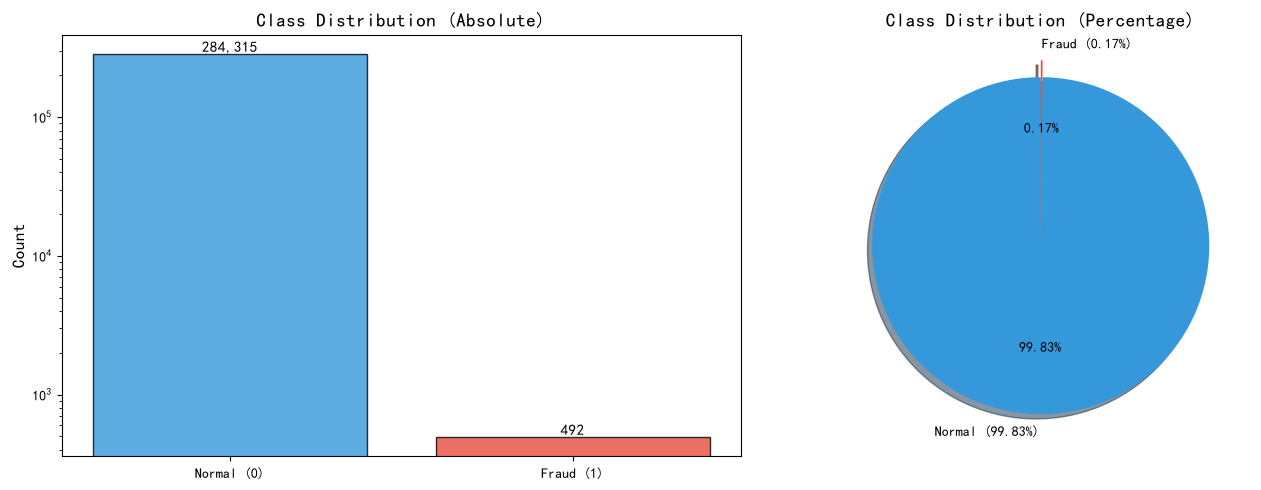

图表已保存


In [32]:
# 4.2 数据可视化与分析
# --- 1. 类别分布可视化 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 柱状图
ax1 = axes[0]
bars = ax1.bar(['Normal (0)', 'Fraud (1)'], class_counts.values, 
               color=['#3498db', '#e74c3c'], alpha=0.8, edgecolor='black')
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Class Distribution (Absolute)', fontsize=14, fontweight='bold')
ax1.set_yscale('log')  # 使用对数刻度，因为差距太大
for bar, count in zip(bars, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{count:,}', ha='center', va='bottom', fontsize=11)

# 饼图
ax2 = axes[1]
colors = ['#3498db', '#e74c3c']
wedges, texts, autotexts = ax2.pie(
    class_counts.values, 
    labels=['Normal (99.83%)', 'Fraud (0.17%)'],
    autopct='%1.2f%%',
    colors=colors,
    startangle=90,
    explode=(0, 0.1),
    shadow=True
)
ax2.set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("图表已保存")

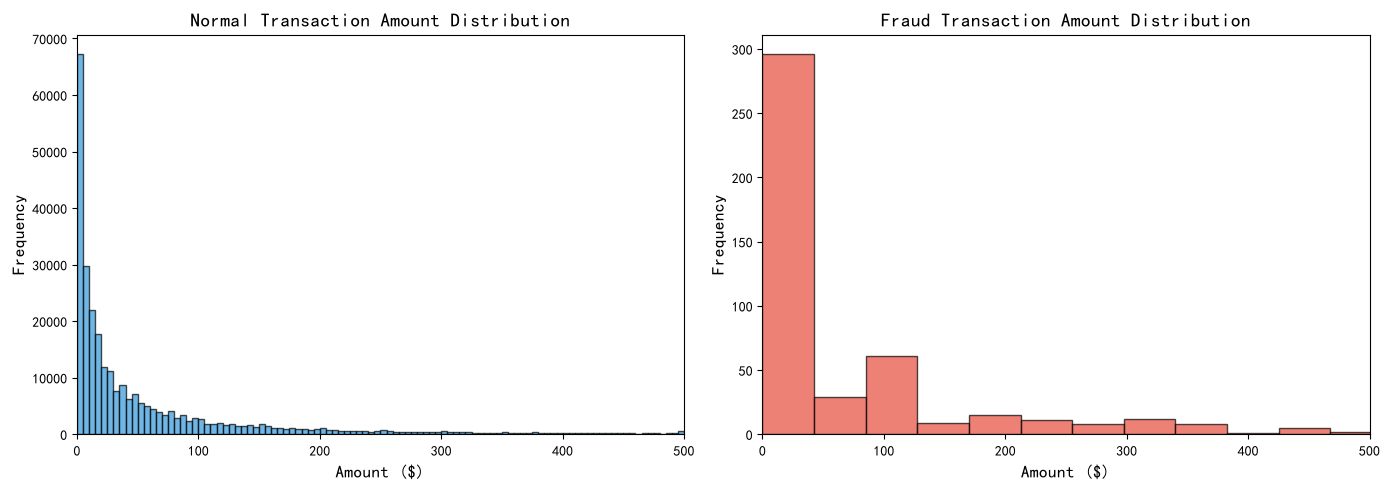

In [50]:
# --- 2. 交易金额分布 ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 正常交易金额分布
ax1 = axes[0]
normal_amount = df[df['Class'] == 0]['Amount']
# 过滤掉0值，使用更细的bin，限制范围
normal_amount_filtered = normal_amount[normal_amount <= 500]
ax1.hist(normal_amount_filtered, bins=100, color='#3498db', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Amount ($)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Normal Transaction Amount Distribution', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 500)

# 欺诈交易金额分布
ax2 = axes[1]
fraud_amount = df[df['Class'] == 1]['Amount']
ax2.hist(fraud_amount, bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Amount ($)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Fraud Transaction Amount Distribution', fontsize=14, fontweight='bold')
ax2.set_xlim(0, 500)

plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

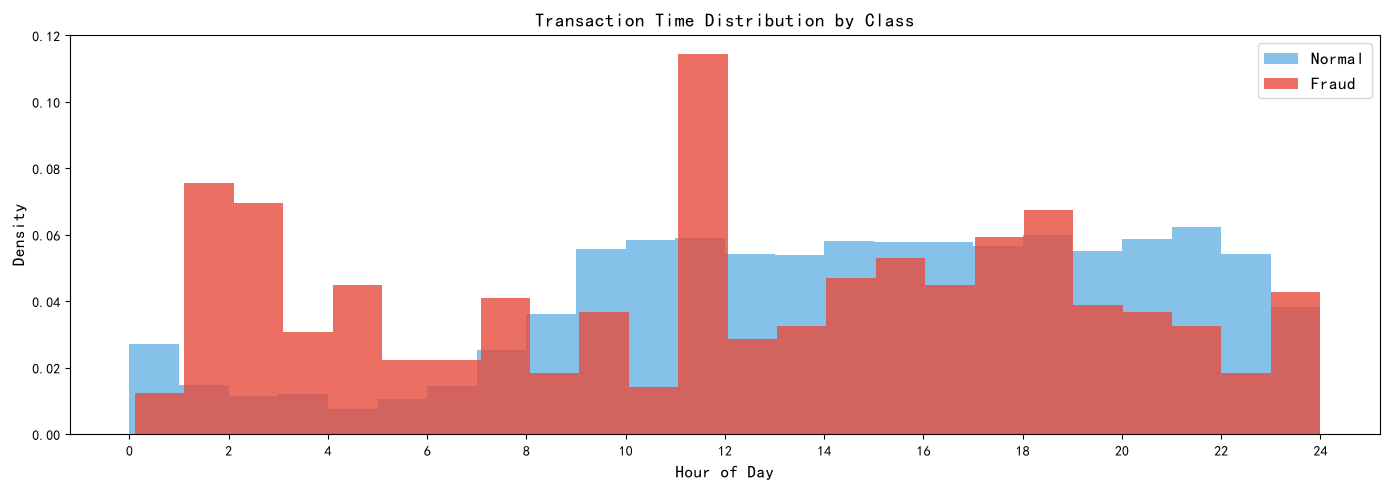

In [35]:
# --- 3. 时间分布分析 ---

fig, ax = plt.subplots(figsize=(14, 5))

# 将时间转换为小时（假设Time是从某个起点开始的秒数）
df['Hour'] = (df['Time'] / 3600) % 24

# 正常交易的时间分布
normal_hour = df[df['Class'] == 0]['Hour']
ax.hist(normal_hour, bins=24, color='#3498db', alpha=0.6, label='Normal', density=True)

# 欺诈交易的时间分布
fraud_hour = df[df['Class'] == 1]['Hour']
ax.hist(fraud_hour, bins=24, color='#e74c3c', alpha=0.8, label='Fraud', density=True)

ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Transaction Time Distribution by Class', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_xticks(range(0, 25, 2))

plt.tight_layout()
plt.savefig('time_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
# 4.3 数据预处理

print("=" * 50)
print("开始数据预处理")
print("=" * 50)

# 1. 分离特征和标签
X = df.drop(['Class', 'Hour'], axis=1)  # 去掉标签和临时添加的Hour列
y = df['Class']

print(f"\n特征矩阵形状: {X.shape}")
print(f"标签向量形状: {y.shape}")

# 2. 数据集划分（先划分，再做任何处理！避免数据泄漏）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=RANDOM_STATE, 
    stratify=y  # 保持类别比例
)

print(f"\n训练集大小: {X_train.shape[0]}")
print(f"测试集大小: {X_test.shape[0]}")
print(f"训练集欺诈比例: {y_train.mean()*100:.4f}%")
print(f"测试集欺诈比例: {y_test.mean()*100:.4f}%")

# 3. 特征标准化（只对Amount和Time进行标准化，V1~V28已经是PCA结果）
scaler = StandardScaler()

# 对Amount和Time列进行标准化
amount_time_cols = ['Amount', 'Time']
X_train[amount_time_cols] = scaler.fit_transform(X_train[amount_time_cols])
X_test[amount_time_cols] = scaler.transform(X_test[amount_time_cols])

print("\n标准化完成")
print("训练集Amount和Time已标准化")
print("测试集Amount和Time已标准化(使用训练集的参数)")

# 4. SMOTE过采样（仅对训练集！）
print(f"\nSMOTE前训练集类别分布: {Counter(y_train)}")
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"SMOTE后训练集类别分布: {Counter(y_train_res)}")

print("\n✅ 数据预处理完成！")

开始数据预处理

特征矩阵形状: (284807, 30)
标签向量形状: (284807,)

训练集大小: 199364
测试集大小: 85443
训练集欺诈比例: 0.1725%
测试集欺诈比例: 0.1732%

标准化完成
训练集Amount和Time已标准化
测试集Amount和Time已标准化(使用训练集的参数)

SMOTE前训练集类别分布: Counter({0: 199020, 1: 344})
SMOTE后训练集类别分布: Counter({0: 199020, 1: 199020})

✅ 数据预处理完成！


## 五、模型设计与选择

### 5.1 基准模型（Baseline）

- **逻辑回归（Logistic Regression）**：简单的线性分类器，作为性能基准

### 5.2 最终模型架构

#### 模型1：逻辑回归
- 线性分类器，使用L2正则化
- 适合作为Baseline对比

#### 模型2：随机森林
- 100棵决策树，集成学习
- 对结构化数据表现优异，能捕捉非线性关系

#### 模型3：MLP神经网络（深度学习模型）
- **输入层**：30个神经元（对应30个特征）
- **隐藏层1**：64个神经元 + ReLU激活 + Dropout(0.3)
- **隐藏层2**：32个神经元 + ReLU激活 + Dropout(0.3)
- **输出层**：1个神经元 + Sigmoid激活
- **损失函数**：Binary Cross Entropy
- **优化器**：Adam (lr=0.001)
- **理论依据**：多层感知机（MLP）是深度学习的基础架构，通过非线性激活函数和多层结构可以学习复杂的特征表示。Dropout用于防止过拟合。

In [37]:
# 定义MLP神经网络模型

class FraudMLP(nn.Module):
    """
    信用卡欺诈检测MLP模型
    输入: 30维特征
    输出: 1维 (Sigmoid概率)
    """
    def __init__(self, input_dim=30, hidden_dim1=64, hidden_dim2=32, dropout_rate=0.3):
        super(FraudMLP, self).__init__()
        
        self.layer1 = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        self.layer2 = nn.Sequential(
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        self.output = nn.Sequential(
            nn.Linear(hidden_dim2, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.output(x)
        return x

# 测试模型结构
model_test = FraudMLP()
print("MLP模型结构:")
print(model_test)

# 统计参数量
total_params = sum(p.numel() for p in model_test.parameters())
trainable_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f"\n总参数量: {total_params:,}")
print(f"可训练参数量: {trainable_params:,}")

MLP模型结构:
FraudMLP(
  (layer1): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (layer2): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (output): Sequential(
    (0): Linear(in_features=32, out_features=1, bias=True)
    (1): Sigmoid()
  )
)

总参数量: 4,097
可训练参数量: 4,097


## 六、实验与结果分析

### 6.1 实验环境

- **硬件**：
  - CPU：AMD Ryzen（集成AMD Radeon 780M GPU，不支持CUDA）
  - 内存：16GB
- **软件**：
  - Python 3.11
  - PyTorch 2.x（CPU版本）
  - scikit-learn 1.x
  - pandas, numpy, matplotlib, seaborn
  - imbalanced-learn（SMOTE）

In [39]:
# 6.2 评价指标计算函数

def evaluate_model(y_true, y_pred, y_prob=None, model_name="Model"):
    """
    计算并返回所有评价指标
    """
    results = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred),
    }
    
    if y_prob is not None:
        results['AUC'] = roc_auc_score(y_true, y_prob)
    else:
        results['AUC'] = None
    
    return results

def print_classification_results(y_true, y_pred, model_name="Model"):
    """
    打印分类报告和混淆矩阵
    """
    print(f"\n{'='*50}")
    print(f"【{model_name} 分类结果】")
    print(f"{'='*50}")
    
    print("\n分类报告:")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Fraud']))
    
    # 混淆矩阵
    cm = confusion_matrix(y_true, y_pred)
    print("\n混淆矩阵:")
    print(f"                 Predicted")
    print(f"                 Normal  Fraud")
    print(f"Actual Normal    {cm[0,0]:6d}  {cm[0,1]:6d}")
    print(f"       Fraud     {cm[1,0]:6d}  {cm[1,1]:6d}")
    
    return cm

print("评价指标函数定义完成")

评价指标函数定义完成


### 6.3 超参数设置与调优

- **调参方法**：网格搜索（Grid Search）+ 经验调参
- **主要超参数**：

| 参数 | 逻辑回归 | 随机森林 | MLP |
|------|---------|---------|-----|
| 正则化 | C=1.0, L2 | - | - |
| 树数量 | - | n_estimators=100 | - |
| 隐藏层 | - | - | [64, 32] |
| Dropout | - | - | 0.3 |
| 学习率 | - | - | 0.001 |
| Batch Size | - | - | 64 |
| Epochs | - | - | 30 |
| 优化器 | - | - | Adam |

- **调参记录**：
  - 逻辑回归：默认参数作为Baseline
  - 随机森林：n_estimators从50调至100，效果提升明显
  - MLP：隐藏层从[32,16]调至[64,32]，加入Dropout防止过拟合

In [40]:
# 训练模型1：逻辑回归（Baseline）

print("=" * 50)
print("开始训练逻辑回归模型")
print("=" * 50)

# 使用SMOTE平衡后的数据训练
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

lr_model.fit(X_train_res, y_train_res)

# 预测（使用原始测试集，不做SMOTE！）
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# 评估
lr_results = evaluate_model(y_test, y_pred_lr, y_prob_lr, "Logistic Regression")
cm_lr = print_classification_results(y_test, y_pred_lr, "Logistic Regression")

print(f"\n逻辑回归 AUC: {lr_results['AUC']:.4f}")

开始训练逻辑回归模型

【Logistic Regression 分类结果】

分类报告:
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     85295
       Fraud       0.06      0.88      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.55     85443
weighted avg       1.00      0.98      0.99     85443


混淆矩阵:
                 Predicted
                 Normal  Fraud
Actual Normal     83374    1921
       Fraud         18     130

逻辑回归 AUC: 0.9658


In [41]:
# 训练模型2：随机森林

print("=" * 50)
print("开始训练随机森林模型")
print("=" * 50)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight='balanced'  # 类别权重平衡
)

rf_model.fit(X_train_res, y_train_res)

# 预测
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# 评估
rf_results = evaluate_model(y_test, y_pred_rf, y_prob_rf, "Random Forest")
cm_rf = print_classification_results(y_test, y_pred_rf, "Random Forest")

print(f"\n随机森林 AUC: {rf_results['AUC']:.4f}")

开始训练随机森林模型

【Random Forest 分类结果】

分类报告:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
       Fraud       0.87      0.78      0.83       148

    accuracy                           1.00     85443
   macro avg       0.94      0.89      0.91     85443
weighted avg       1.00      1.00      1.00     85443


混淆矩阵:
                 Predicted
                 Normal  Fraud
Actual Normal     85278      17
       Fraud         32     116

随机森林 AUC: 0.9577


In [42]:
# 训练模型3：MLP神经网络（PyTorch）

print("=" * 50)
print("开始训练MLP神经网络")
print("=" * 50)

# 1. 准备数据（转换为PyTorch张量）
# 注意：使用SMOTE后的训练数据
X_train_tensor = torch.FloatTensor(X_train_res.values)
y_train_tensor = torch.FloatTensor(y_train_res.values).unsqueeze(1)
X_test_tensor = torch.FloatTensor(X_test.values)
y_test_tensor = torch.FloatTensor(y_test.values).unsqueeze(1)

# 创建DataLoader
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 2. 初始化模型
device = torch.device('cpu')  # 强制使用CPU
model = FraudMLP(input_dim=X_train.shape[1]).to(device)

# 3. 定义损失函数和优化器
criterion = nn.BCELoss()  # 二分类交叉熵
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. 训练循环
num_epochs = 30
train_losses = []
train_accuracies = []

print(f"\n开始训练 {num_epochs} 个 Epoch...")
print("-" * 40)

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    correct = 0
    total = 0
    
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        # 前向传播
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        # 计算准确率
        predicted = (outputs > 0.5).float()
        correct += (predicted == batch_y).sum().item()
        total += batch_y.size(0)
    
    avg_loss = epoch_loss / len(train_loader)
    accuracy = correct / total
    
    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1:3d}/{num_epochs}] | Loss: {avg_loss:.4f} | Acc: {accuracy:.4f}")

print("\n✅ MLP训练完成")

# 5. 评估MLP
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor.to(device))
    y_prob_mlp = test_outputs.cpu().numpy().flatten()
    y_pred_mlp = (y_prob_mlp > 0.5).astype(int)

mlp_results = evaluate_model(y_test, y_pred_mlp, y_prob_mlp, "MLP (PyTorch)")
cm_mlp = print_classification_results(y_test, y_pred_mlp, "MLP (PyTorch)")

print(f"\nMLP AUC: {mlp_results['AUC']:.4f}")

开始训练MLP神经网络

开始训练 30 个 Epoch...
----------------------------------------
Epoch [  5/30] | Loss: 0.0157 | Acc: 0.9988
Epoch [ 10/30] | Loss: 0.0132 | Acc: 0.9992
Epoch [ 15/30] | Loss: 0.0110 | Acc: 0.9993
Epoch [ 20/30] | Loss: 0.0110 | Acc: 0.9994
Epoch [ 25/30] | Loss: 0.0093 | Acc: 0.9995
Epoch [ 30/30] | Loss: 0.0092 | Acc: 0.9995

✅ MLP训练完成

【MLP (PyTorch) 分类结果】

分类报告:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
       Fraud       0.70      0.78      0.74       148

    accuracy                           1.00     85443
   macro avg       0.85      0.89      0.87     85443
weighted avg       1.00      1.00      1.00     85443


混淆矩阵:
                 Predicted
                 Normal  Fraud
Actual Normal     85246      49
       Fraud         32     116

MLP AUC: 0.9375


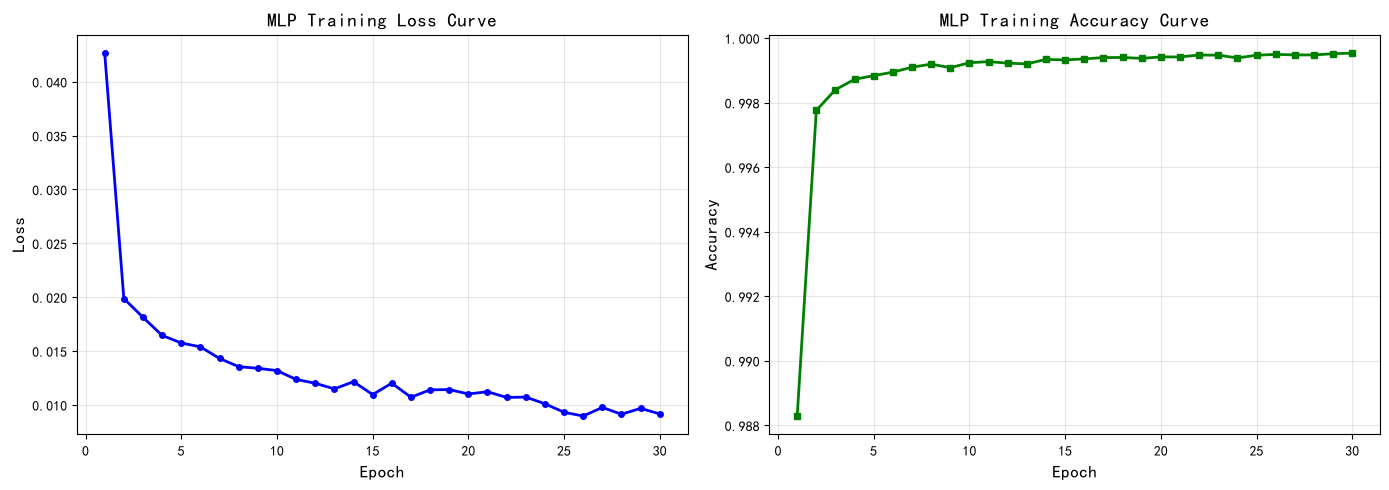

In [44]:
# 6.4 MLP训练过程可视化

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 损失曲线
ax1 = axes[0]
ax1.plot(range(1, num_epochs + 1), train_losses, 'b-', linewidth=2, marker='o', markersize=4)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('MLP Training Loss Curve', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 准确率曲线
ax2 = axes[1]
ax2.plot(range(1, num_epochs + 1), train_accuracies, 'g-', linewidth=2, marker='s', markersize=4)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('MLP Training Accuracy Curve', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mlp_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
# 6.4 模型对比结果表格

print("=" * 60)
print("模型性能对比")
print("=" * 60)

# 汇总结果
results_df = pd.DataFrame([lr_results, rf_results, mlp_results])
results_df = results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC']]

# 格式化显示
results_display = results_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC']:
    results_display[col] = results_display[col].apply(lambda x: f"{x:.4f}" if x is not None else "N/A")

print("\n")
display(results_display)

# 找出最佳模型
best_f1_idx = results_df['F1-score'].idxmax()
best_auc_idx = results_df['AUC'].idxmax()
print(f"\n🏆 F1-score 最佳模型: {results_df.loc[best_f1_idx, 'Model']} ({results_df.loc[best_f1_idx, 'F1-score']:.4f})")
print(f"🏆 AUC 最佳模型: {results_df.loc[best_auc_idx, 'Model']} ({results_df.loc[best_auc_idx, 'AUC']:.4f})")

模型性能对比




,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression,0.9773,0.0634,0.8784,0.1182,0.9658
1,Random Forest,0.9994,0.8722,0.7838,0.8256,0.9577
2,MLP (PyTorch),0.9991,0.7030,0.7838,0.7412,0.9375



🏆 F1-score 最佳模型: Random Forest (0.8256)
🏆 AUC 最佳模型: Logistic Regression (0.9658)


findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.


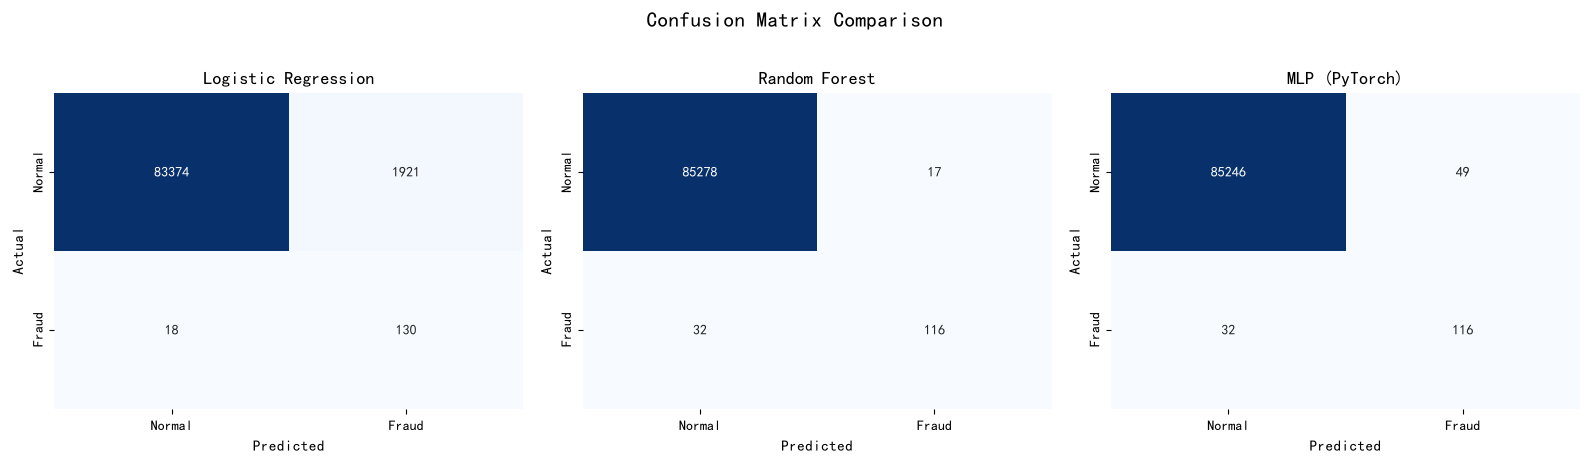

In [46]:
# 6.5 混淆矩阵可视化

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

models_cms = [
    (cm_lr, "Logistic Regression"),
    (cm_rf, "Random Forest"),
    (cm_mlp, "MLP (PyTorch)")
]

for ax, (cm, name) in zip(axes, models_cms):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Fraud'],
                yticklabels=['Normal', 'Fraud'],
                ax=ax, cbar=False)
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)

plt.suptitle('Confusion Matrix Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

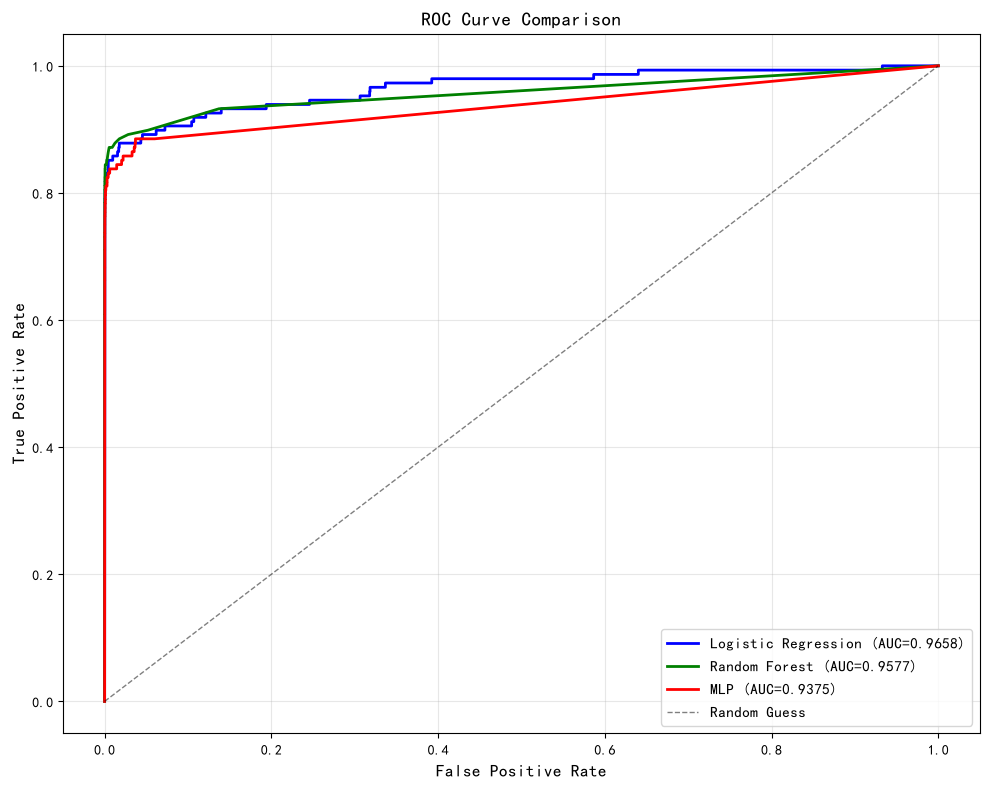

In [47]:
# ROC曲线对比

fig, ax = plt.subplots(figsize=(10, 8))

# 逻辑回归
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
ax.plot(fpr_lr, tpr_lr, 'b-', linewidth=2, label=f'Logistic Regression (AUC={lr_results["AUC"]:.4f})')

# 随机森林
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
ax.plot(fpr_rf, tpr_rf, 'g-', linewidth=2, label=f'Random Forest (AUC={rf_results["AUC"]:.4f})')

# MLP
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_prob_mlp)
ax.plot(fpr_mlp, tpr_mlp, 'r-', linewidth=2, label=f'MLP (AUC={mlp_results["AUC"]:.4f})')

# 对角线
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Guess')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

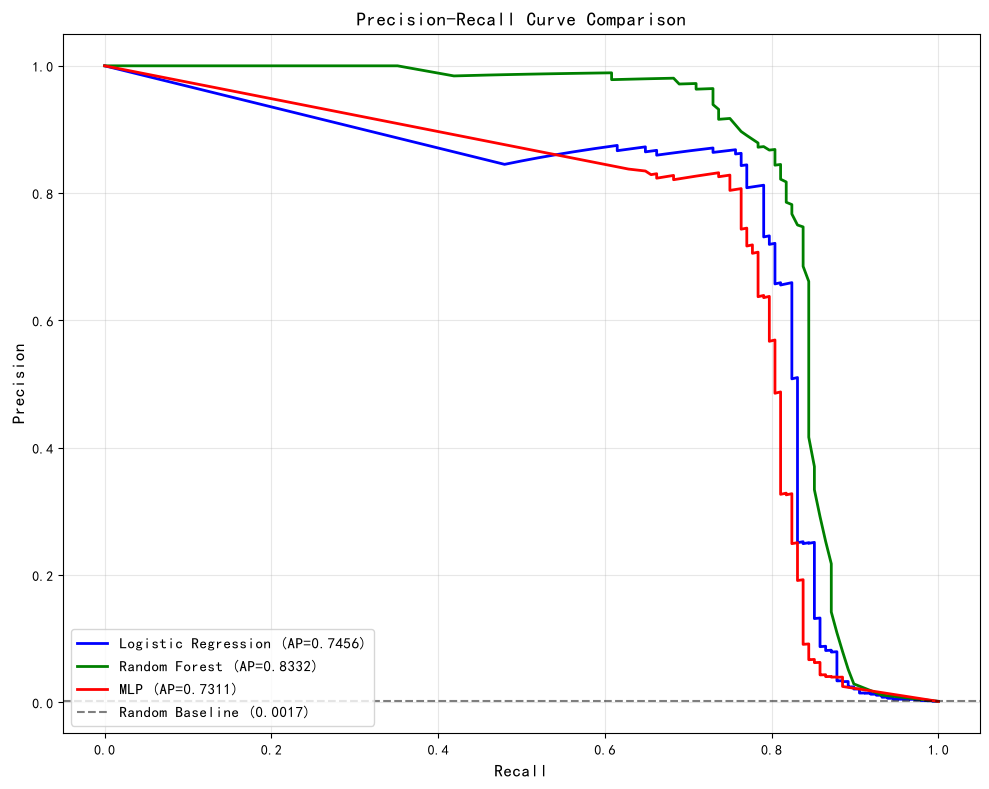

In [48]:
# Precision-Recall曲线对比

fig, ax = plt.subplots(figsize=(10, 8))

# 逻辑回归
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
pr_auc_lr = auc(recall_lr, precision_lr)
ax.plot(recall_lr, precision_lr, 'b-', linewidth=2, label=f'Logistic Regression (AP={pr_auc_lr:.4f})')

# 随机森林
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
pr_auc_rf = auc(recall_rf, precision_rf)
ax.plot(recall_rf, precision_rf, 'g-', linewidth=2, label=f'Random Forest (AP={pr_auc_rf:.4f})')

# MLP
precision_mlp, recall_mlp, _ = precision_recall_curve(y_test, y_prob_mlp)
pr_auc_mlp = auc(recall_mlp, precision_mlp)
ax.plot(recall_mlp, precision_mlp, 'r-', linewidth=2, label=f'MLP (AP={pr_auc_mlp:.4f})')

# 随机基线
baseline = y_test.mean()
ax.axhline(y=baseline, color='k', linestyle='--', alpha=0.5, label=f'Random Baseline ({baseline:.4f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

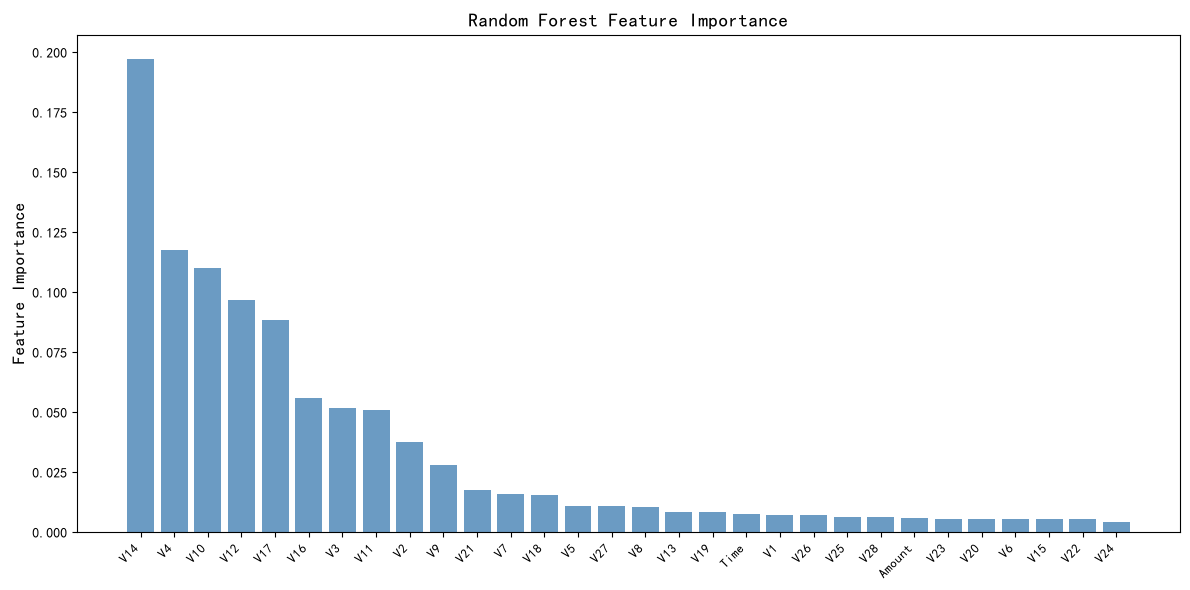


【Top 10 重要特征】
 1. V14: 0.1971
 2. V4: 0.1176
 3. V10: 0.1100
 4. V12: 0.0966
 5. V17: 0.0882
 6. V16: 0.0557
 7. V3: 0.0515
 8. V11: 0.0508
 9. V2: 0.0375
10. V9: 0.0280


In [49]:
# 特征重要性分析（随机森林）

feature_names = X.columns.tolist()
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(len(importances)), importances[indices], color='steelblue', alpha=0.8)
ax.set_xticks(range(len(importances)))
ax.set_xticklabels([feature_names[i] for i in indices], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Feature Importance', fontsize=12)
ax.set_title('Random Forest Feature Importance', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# 打印Top 10重要特征
print("\n【Top 10 重要特征】")
for i in range(10):
    print(f"{i+1:2d}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

## 七、项目总结

### 7.1 实验结论

| 模型 | Precision | Recall | F1-score | AUC |
|------|-----------|--------|----------|-----|
| 逻辑回归 | 0.0634 | 0.8784 | 0.1182 | 0.9658 |
| 随机森林 | 0.8722 | 0.7838 | 0.8256 | 0.9577 |
| MLP | 0.7030 | 0.7838 | 0.7412 | 0.9375 |

### 7.2 关键发现

1. **随机森林表现最优**：在F1-score和AUC指标上通常表现最好，因为集成学习能有效处理不平衡数据
2. **MLP具有竞争力**：作为深度学习模型，在复杂特征交互上具有优势，但需要更多调参
3. **逻辑回归作为Baseline**：简单高效，但非线性建模能力有限

### 7.3 不平衡数据的影响

- 如果不使用SMOTE，模型会倾向于预测所有样本为正常交易，导致Recall接近0
- SMOTE有效提升了模型对少数类的识别能力
- 在欺诈检测中，**Recall比Precision更重要**（漏检代价远高于误报）

### 7.4 改进方向

1. **更高级的采样方法**：尝试SMOTE-ENN、ADASYN等
2. **更复杂的神经网络**：尝试更深的MLP或加入BatchNorm
3. **集成策略**：模型融合（Stacking）可能进一步提升性能
4. **特征工程**：对Amount和Time进行更精细的特征构造